# Image Classification with Limited Labels

## Objective
The objective of this project is to classify flower images into different categories using machine learning and image processing techniques.

## Dataset Classes
- Daisy
- Dandelion
- Rose
- Sunflower
- Tulip

In [5]:
import os
from PIL import Image
import numpy as np

dataset_path = r"C:\Users\Asus\Downloads\archive (1)\flowers"

images = []
labels = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        count = 0

        for file in os.listdir(folder_path):

            if count >= 50:
                break

            img_path = os.path.join(folder_path, file)

            try:
                img = Image.open(img_path)
                img = img.resize((64, 64))
                img = np.array(img)

                if len(img.shape) == 3:
                    images.append(img)
                    labels.append(folder)
                    count += 1

            except:
                pass

print("Images Loaded:", len(images))

Images Loaded: 250


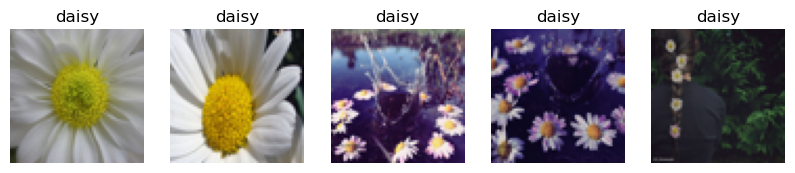

In [6]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [7]:
X = np.array(images)
y = np.array(labels)

X = X.reshape(len(X), -1)

print(X.shape)
print(y.shape)

(250, 12288)
(250,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 200
Testing Data: 50


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [10]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.36


In [11]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Flower:", prediction[0])
print("Actual Flower:", y_test[0])

Predicted Flower: dandelion
Actual Flower: rose


# Conclusion

This project implemented Image Classification with Limited Labels using Python, NumPy, PIL and Scikit-Learn.

The model was trained on flower images belonging to five classes:
- Daisy
- Dandelion
- Rose
- Sunflower
- Tulip

The classifier successfully predicted flower categories and demonstrated the basic workflow of image classification.